In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [35]:
df = pd.read_csv(r'C:\Users\Muhammad Saad\OneDrive\Desktop\Sms spam classifier\spam.csv',encoding='latin-1')

In [36]:
df.head(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN


In [37]:
df.head(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN


In [38]:
df = df[['v2','v1']]

In [39]:
df.head(2)

,v2,v1
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham


DATA CLEANING

In [40]:
df.rename(columns={'v2':'text','v1':'label'},inplace=True)

In [41]:
df

,text,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,spam
5568,Will Ì_ b going to esplanade fr home?,ham
5569,"Pity, * was in mood for that. So...any other s...",ham
5570,The guy did some bitching but I acted like i'd...,ham


In [42]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [43]:
df.duplicated().sum()

np.int64(403)

In [44]:
df.drop_duplicates(inplace=True)

In [45]:
df.duplicated().sum()

np.int64(0)

<Axes: >

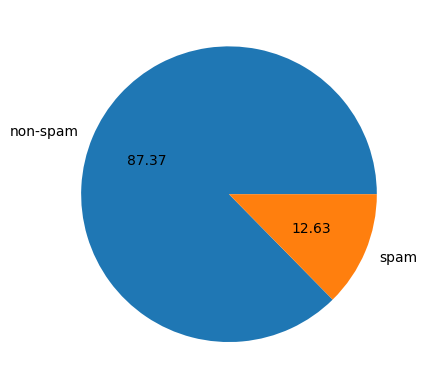

In [46]:
df['label'].value_counts().plot(kind='pie',autopct='%0.2f',labels=['non-spam','spam'])

In [47]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Muhammad
[nltk_data]     Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [48]:
df['no of characters'] = df['text'].apply(len)

In [49]:
df

,text,label,no of characters
0,"Go until jurong point, crazy.. Available only ...",0,111
1,Ok lar... Joking wif u oni...,0,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,U dun say so early hor... U c already then say...,0,49
4,"Nah I don't think he goes to usf, he lives aro...",0,61
...,...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1,161
5568,Will Ì_ b going to esplanade fr home?,0,37
5569,"Pity, * was in mood for that. So...any other s...",0,57
5570,The guy did some bitching but I acted like i'd...,0,125


In [50]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to C:\Users\Muhammad
[nltk_data]     Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [51]:
df['number of words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [52]:
df['num of sent'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [53]:
df[['no of characters','number of words','num of sent']].describe()

,no of characters,number of words,num of sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [54]:
ham = df[df['label'] == 0][['no of characters','number of words','num of sent']]

In [55]:
spam = df[df['label'] == 1][['no of characters','number of words','num of sent']]

<Axes: xlabel='no of characters', ylabel='Count'>

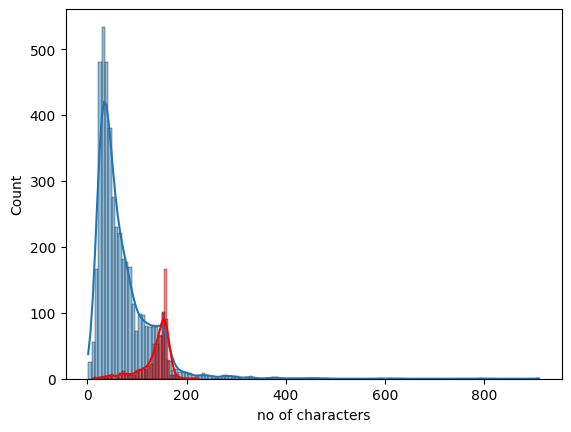

In [56]:
sns.histplot(df[df['label']==0],x='no of characters',kde=True)
sns.histplot(df[df['label']==1],x='no of characters',kde=True,color='red')


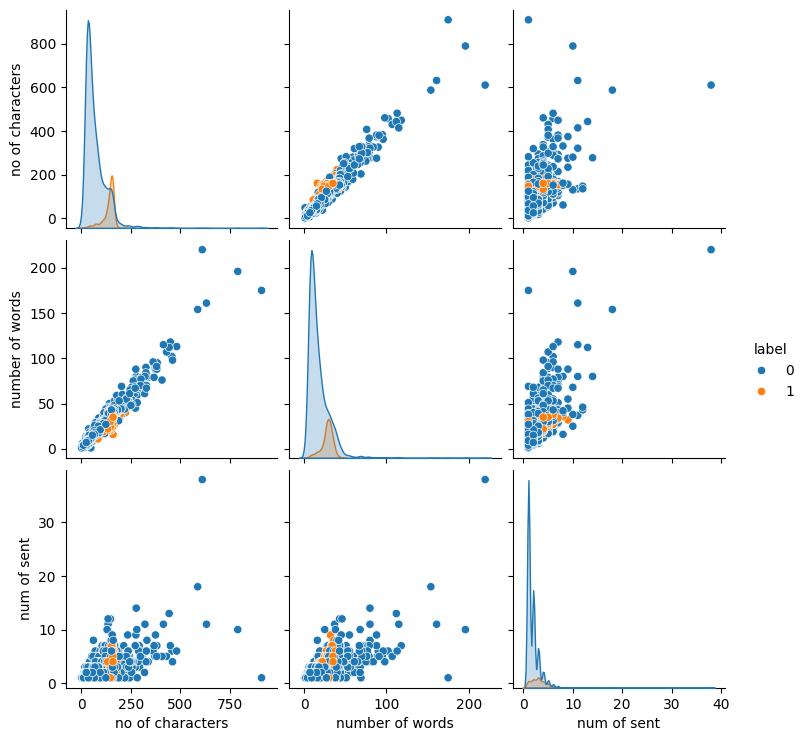

In [57]:
sns.pairplot(df,hue='label')

In [58]:
df.corr(numeric_only=True)

,label,no of characters,number of words,num of sent
label,1.000000,0.384717,0.262912,0.263939
no of characters,0.384717,1.000000,0.965760,0.624139
number of words,0.262912,0.965760,1.000000,0.679971
num of sent,0.263939,0.624139,0.679971,1.000000


<Axes: >

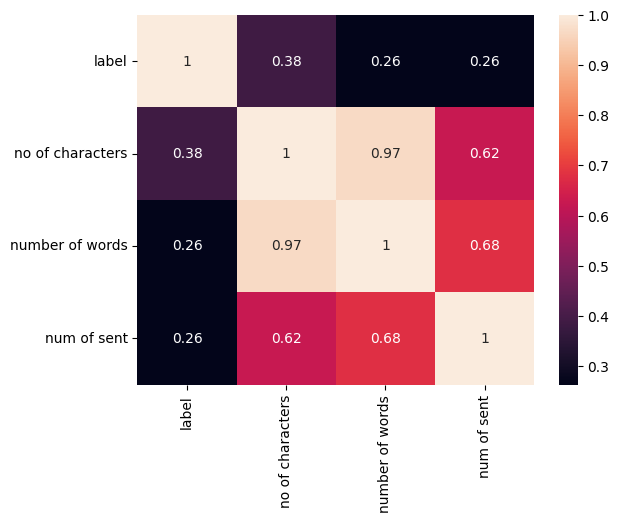

In [59]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

TEXT PREPROCESSING

. Lower Case
. Tokenization
. Removing special characters
. Removing stop words and punctuation
. Stemming

In [60]:
from nltk.corpus import stopwords
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [61]:
def transformation(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    t = []
    for i in text:
        if i.isalnum():
            t.append(i)
    
    text = t[:]
    t.clear()
    for j in text:
        if j not in stopwords.words('english') and j not in string.punctuation:
            t.append(j)
    text = t[:]
    t.clear()
    for k in text:
        ps.stem(k)
        t.append(ps.stem(k))

    return t

In [67]:
transformation("i am loving cared? what's your opinion!")

['love', 'care', 'opinion']

In [66]:
df['transformed text'] = df['text'].apply(transformation)

In [65]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Muhammad
[nltk_data]     Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [64]:
stopwords.words('english')[-2]

'yourselves'

In [63]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('cared')

'care'

In [69]:
df.head(1)

,text,label,no of characters,number of words,num of sent,transformed text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."


In [78]:
exact_words = []
for mesg in df[df['label'] == 1]['transformed text'].to_list():
    for word in mesg:
        exact_words.append(word)

In [80]:
exact_words[:10]

['free', 'entri', '2', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt']

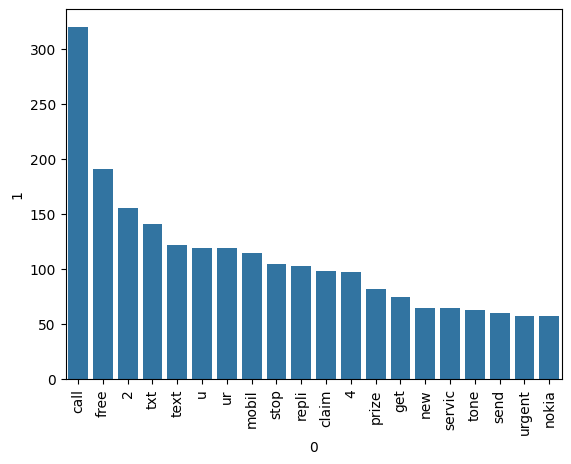

In [88]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(exact_words).most_common(20)).sort_values(by=1,ascending=False),x=0,y=1)
plt.xticks(rotation=90)
plt.show()

In [89]:
exact_words_ham = []
for mesg in df[df['label'] == 0]['transformed text'].to_list():
    for word in mesg:
        exact_words_ham.append(word)

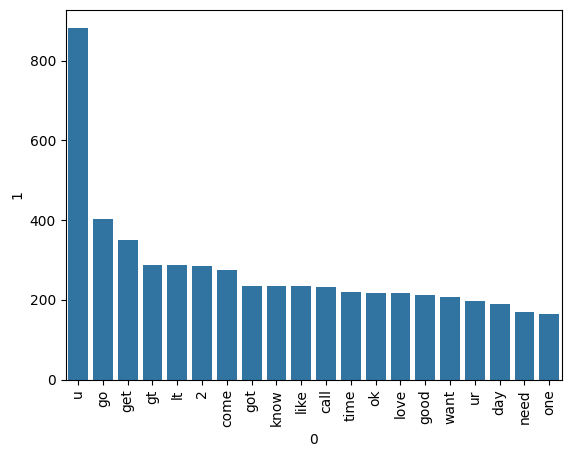

In [93]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(exact_words_ham).most_common(20)).sort_values(by=1,ascending=False),x=0,y=1)
plt.xticks(rotation=90)
plt.show()

MODEL BUILDING

In [101]:
df['transformed text'].head()

0    [go, jurong, point, crazi, avail, bugi, n, gre...
1                         [ok, lar, joke, wif, u, oni]
2    [free, entri, 2, wkli, comp, win, fa, cup, fin...
3        [u, dun, say, earli, hor, u, c, alreadi, say]
4         [nah, think, goe, usf, live, around, though]
Name: transformed text, dtype: object

In [ ]:
# As we can see that the transformed text column is not in numeric form and a machine learning model cannot understand text data so we have to convert it into numeric form. We will do this by using the bag of words technique  or tfidf technique. We will use both techniques and compare the results.

In [142]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [143]:
x = cv.fit_transform(df['transformed text'].apply(lambda x: ' '.join(x))).toarray()

In [144]:
y = df['label'].values

In [145]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [146]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB
mln = MultinomialNB()
gsn = GaussianNB()
bnn = BernoulliNB()


In [147]:
mln.fit(x_train,y_train)
y_pred = mln.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9738878143133463
0.8881578947368421
[[872  17]
 [ 10 135]]


In [148]:
bnn.fit(x_train,y_train)
y_pred1 = bnn.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

0.9661508704061895
0.9661016949152542
[[885   4]
 [ 31 114]]


In [149]:
gsn.fit(x_train,y_train)
y_pred2 = gsn.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

0.8684719535783365
0.5185185185185185
[[772 117]
 [ 19 126]]


In [114]:

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score


# tfidf ,bnn

In [152]:
import XGBoost

ModuleNotFoundError: No module named 'XGBoost'

In [153]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [154]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [155]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [156]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision